<a href="https://colab.research.google.com/github/GayatriVidhate23/Pattern-Recognition-/blob/main/PRAC_05_CM23039.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

df.head()

Saving Mall_Customers.csv to Mall_Customers.csv


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(df.shape)

df.info()

df.describe()

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [5]:
encoder = LabelEncoder()

df['Gender'] = encoder.fit_transform(df['Gender'])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [6]:
X = df.drop('CustomerID', axis=1)

X.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

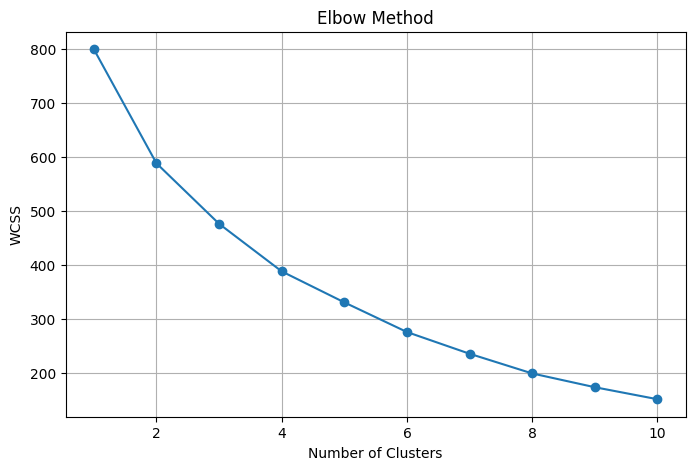

In [9]:
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['KMeans Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans Cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,3
2,3,0,20,16,6,3
3,4,0,23,16,77,3
4,5,0,31,17,40,3


In [11]:
print(df['KMeans Cluster'].value_counts())

KMeans Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64


In [12]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(
    centers,
    columns=X.columns
)

print(centers)

         Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  4.615385e-01  32.692308           86.538462               82.128205
1  4.482759e-01  36.482759           89.517241               18.000000
2 -5.551115e-17  49.813953           49.232558               40.069767
3  4.074074e-01  24.907407           39.722222               61.203704
4  1.000000e+00  55.714286           53.685714               36.771429


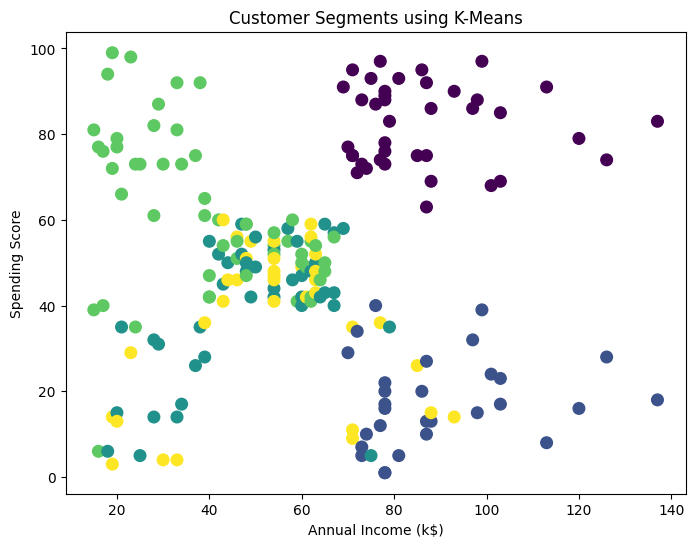

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['KMeans Cluster'],
    cmap='viridis',
    s=70
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.title("Customer Segments using K-Means")

plt.show()

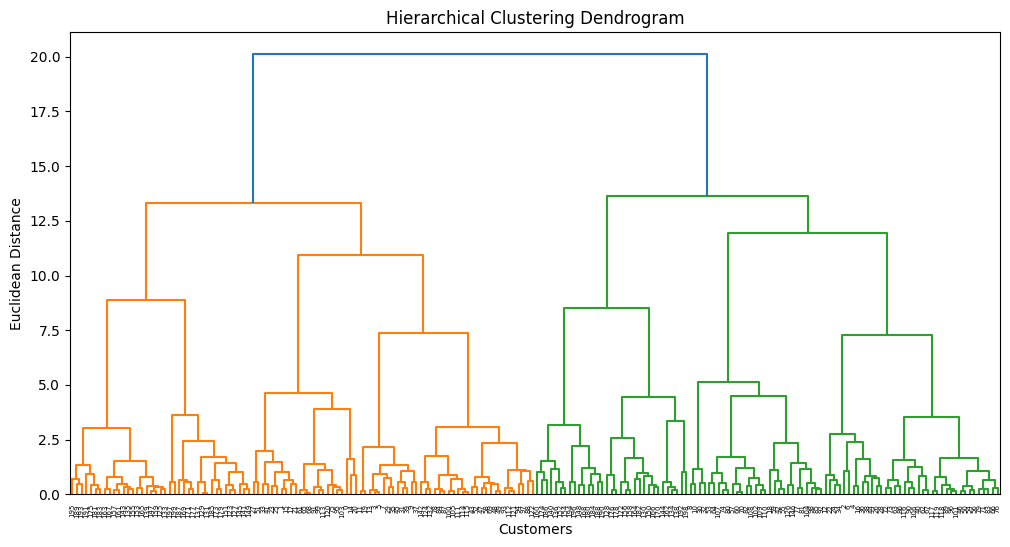

In [14]:
linked = linkage(
    X_scaled,
    method='ward'
)

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.xlabel("Customers")

plt.ylabel("Euclidean Distance")

plt.show()

In [15]:
hc = AgglomerativeClustering(
    n_clusters=5
)

df['Hierarchical Cluster'] = hc.fit_predict(X_scaled)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans Cluster,Hierarchical Cluster
0,1,1,19,15,39,3,0
1,2,1,21,15,81,3,0
2,3,0,20,16,6,3,3
3,4,0,23,16,77,3,0
4,5,0,31,17,40,3,3


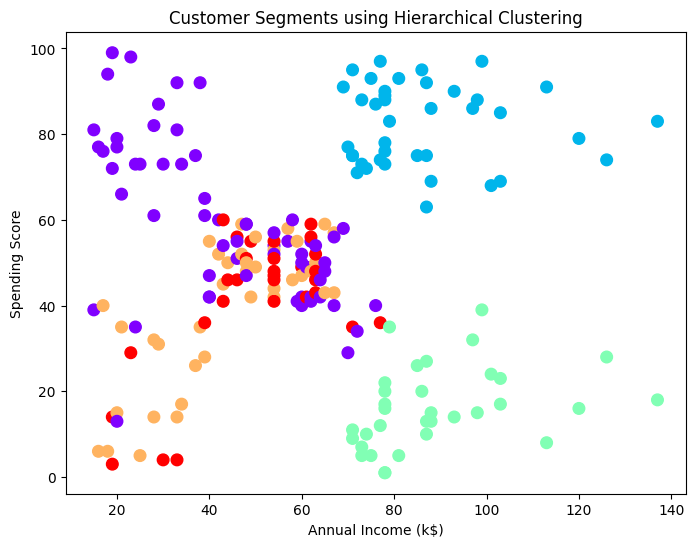

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Hierarchical Cluster'],
    cmap='rainbow',
    s=70
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.title("Customer Segments using Hierarchical Clustering")

plt.show()

In [17]:
summary = df.groupby('KMeans Cluster').mean(numeric_only=True)

print(summary)

                CustomerID    Gender        Age  Annual Income (k$)  \
KMeans Cluster                                                        
0               162.000000  0.461538  32.692308           86.538462   
1               165.482759  0.448276  36.482759           89.517241   
2                73.651163  0.000000  49.813953           49.232558   
3                52.814815  0.407407  24.907407           39.722222   
4                84.685714  1.000000  55.714286           53.685714   

                Spending Score (1-100)  Hierarchical Cluster  
KMeans Cluster                                                
0                            82.128205              1.000000  
1                            18.000000              1.793103  
2                            40.069767              2.604651  
3                            61.203704              0.111111  
4                            36.771429              3.600000  
